# ML Lab - Midterm: Kernel Regression (20 marks)

Use the provided `diabetes_dataset.csv` (10 features + `target`). Write clean, well-commented code.

You may **not** access the internet during the exam. Set `random_state=42` where asked.

In this problem, you will perform Gaussian kernel regression using the following formula:

<img src="Kernel_Function.png" alt="alt text for screen readers" width="50%">



where $x_i$ is the $i$-th training sample and $y_i$ is the corresponding target value; $M$ is the total number of training samples, and $y^*$ is the prediction for the test sample $x^*$; the exponential functions denote a Gaussian kernel with variance $\sigma^2$.

## Tasks (20 marks total)


In [1]:
import numpy as np
import pandas as pd 
import sklearn
import seaborn as sns

### Task 1: Load the Diabetes Dataset  (1 Mark)
- Load the **diabetes dataset**.  
- Note: The dataset the dataset is provided as a **CSV file**. 
  


In [ ]:
# Solution
from sklearn import datasets
diabetes = datasets.load_diabetes(scaled=False)

# converting to pandas dataframe 
x = pd.DataFrame(diabetes.data)
y = pd.DataFrame(diabetes.target)

# dropping the categorical column
x = x.drop(columns = 1)
print(x.head())

      0     2      3      4      5     6    7       8     9
0  59.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0


### Task 2: Train-Test Split  (1 Mark)
- Split the dataset into **training (80%)** and **testing (20%)** sets.  
- Set `random_state=42`

In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(diabetes.data, y, test_size=0.2, random_state=42)

### Task 3: Standardization of Features (2 Marks)
- Standardize the features using **StandardScaler** from *scikit-learn* (`sklearn.preprocessing`).


In [67]:
# Solution
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Task 4: Kernel Regression Implementation  (7 Marks)
- Implement **kernel regression** using the above **given formula** (Gaussian kernel).  
- Use the value of **parameter (σ)** as 1.02836.  

In [ ]:
# Solution
from scipy.stats import norm
class GaussianKernel:

    # Defining parameters for class 
    def __init__(self, sigma = 1.02836):
        self.sigma = sigma
        self.X = None
        self.y = None

    def fit(self, X, y):
        self.X = X
        self.y = y.ravel()

    # Calculations using Gaussian Kernel Regression formula
    def calc(self, sample):

        # A = (x* - xi)^2/(2σ^2)

        A = ((self.X - sample)**2).sum(axis = 1)/(2*self.sigma**2)

        B = np.exp(-A)
        
        return (B*self.y).sum()/B.sum()
    
    # Storing and returning predictions
    def predict(self, X):
        preds = []
        for sample in X:
            y.pred = self.calc(sample)
            preds.append(y.pred)
        return np.array(preds)

### Task 5: Prediction and Evaluation  (3 Marks)
- Perform predictions on the **test set** using your kernel regression model and the given **sigma**.  
- Report **Mean Squared Error (MSE)** and **R² score** on the test set.  


In [93]:
# Solution
gk = GaussianKernel()
gk.fit(x_train_scaled, y_train.to_numpy())

In [94]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_pred = gk.predict(x_test_scaled)

mse_test_scratch=mean_squared_error(y_test, y_pred)
print("MSE:", mse_test_scratch)
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2967.1640804212766
R2 Score: 0.4399624206211089


### Task 6: Scatter Plot of Predictions  (2 Marks)
- Show a scatter plot of **Predicted values vs. Ground truth values**. 

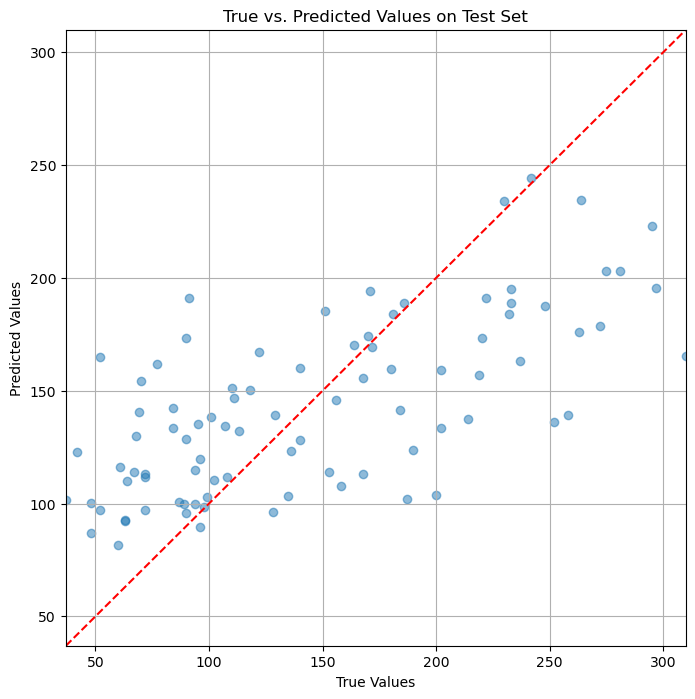

In [80]:
# Solution
import matplotlib.pyplot as plt
y_test_np = y_test.values.flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_test_np, y_pred, alpha=0.5)

min_val = min(y_test_np.min(), y_pred.min())
max_val = max(y_test_np.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs. Predicted Values on Test Set")

plt.grid(True)

plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

plt.show()

### Task 7: Model Type and Justification  (1.5 + 2.5 = 4 Marks)
- What type of regression model have you implemented?  
- **Justify your answer**   

In [85]:
# Solution
from sklearn.neighbors import KNeighborsRegressor
model_distance = KNeighborsRegressor(
    n_neighbors=3,
    p=1.0,
    algorithm='brute',
    weights='uniform'
)
model_distance.fit(x_train_scaled, y_train)
y_pred_distance = model_distance.predict(x_test_scaled)
r2_distance = r2_score(y_test, y_pred_distance)
print(f"R²={r2_distance:.4f}")

R²=0.3807


The model is close to the KNNRegressor as we can see the difference of r2_score of both models is less than 0.1

## Submission Guidelines

- All code must be well commented for clarity  
- All plots must be properly labeled  
- Both .ipynb and .py files must be submitted to receive credit. The submission should be uploaded in a single .zip file named YourRollNumber_midsem.zip.  
- The individual files within the .zip should be named YourRollNumber_midsem.py and YourRollNumber_midsem.ipynb  
